# Part 3 — latent geometry: AE-only vs. joint BCE

First link in the AE-only → BCE → contrastive geometry chain (`part_7` continues into
the contrastive ablations from here). Exploratory / "for fun": does adding the
molecule-classification head change the encoder's latent geometry at all, and if so,
how? Methodology: `../report/geometria_latentu.md` — every statistic below operates on
canonicalized $u = (z-\beta)/\gamma$, never on raw $z$ (§4), because $\gamma,\beta$
are learned independently per model and would otherwise contaminate every comparison
with each model's own `LayerNorm` scale rather than its representation.

Compares the same two models as `part_1`:

- `kidney-architecture-binning`, `grid_0010` — reconstruction-only baseline ("AE-only").
- `kidney-architecture-predictive`, `grid_0000` — joint reconstruction + `balanced_bce`
  head ("BCE").

Scope: **train and test splits only** — validation is not needed for this comparison
(unlike `part_1`, where it was kept for completeness on the reconstruction question).


In [1]:
import os
from dataclasses import replace
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.latent import sphere_geometry as geometry
from msi_autoencoder_wrapper.visualization import resolve_theme


2026-08-28 00:14:17,961 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 00:14:17,964 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-28 00:14:18,672 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-28 00:14:18,675 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-28 00:14:18,678 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-28 00:14:18,679 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 00:14:18,697 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-28 00:14:18,835 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-28 00:14:18,837 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"

BASELINE_MODEL_NAME = "kidney-architecture-binning__cfg_d1feaa5d34e5__grid_0010__rep_00"
PREDICTIVE_MODEL_NAME = "kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_00"
MODEL_LABELS = {"baseline": "AE-only", "predictive": "BCE"}

BATCH_SIZE = 256
RANDOM_SEED = 42
PAIR_COUNT = 20000  # random-pair sample size for structure_test / rsa_spearman
KNN_K = 10

theme = resolve_theme(None)
theme.apply()
model_colors = {label: theme.color_for_model(label, index) for index, label in enumerate(MODEL_LABELS.values())}
theme = replace(theme, model_overrides=model_colors)
theme.apply()


## Load both models and their shared pixels

Same `/tmp` scratch-path workaround as `part_1`/`part_2` for the predictive-campaign
model's annotation-store path.


In [3]:
SCRATCH_WORKSPACE_ROOT = Path("/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace")
SCRATCH_WORKSPACE_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not SCRATCH_WORKSPACE_ROOT.is_symlink():
    SCRATCH_WORKSPACE_ROOT.symlink_to(WORKSPACE.resolve())

wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

wrapper.load_configuration(model_name=BASELINE_MODEL_NAME)
baseline_partitions = wrapper.active_dataset.create_partitions()
baseline_model = wrapper.active_model
baseline_model.eval()
baseline_gamma, baseline_beta = geometry.encoder_layer_norm_parameters(baseline_model)

wrapper.load_configuration(model_name=PREDICTIVE_MODEL_NAME)
predictive_partitions = wrapper.active_dataset.create_partitions()
predictive_model = wrapper.active_model
predictive_model.eval()
predictive_gamma, predictive_beta = geometry.encoder_layer_norm_parameters(predictive_model)

shared_ids_by_split = {}
for split_name in ("train", "test"):
    baseline_ids = set(baseline_partitions.manifest.assignments[split_name])
    predictive_ids = set(predictive_partitions.manifest.assignments[split_name])
    shared_ids_by_split[split_name] = sorted(baseline_ids & predictive_ids)
    print(f"{split_name}: {len(shared_ids_by_split[split_name])} pixel(s) shared by both models")


2026-08-28 00:14:19,612 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-28 00:14:19,614 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-28 00:14:19,615 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-28 00:14:19,616 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 00:14:19,617 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-28 00:15:36,212 | INFO     | msi_autoencoder_wrapper.configuration.orchestrator:74 | Saved configuration restoration completed.


2026-08-28 00:15:36,213 | INFO     | msi_autoencoder_wrapper.core.mixins.active_context.active_context_mixin:113 | Successfully bound active context memory maps for: kidney


2026-08-28 00:15:55,371 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:203 | Mapped annotation index: retained_rows=420649 retained_entries=10495756 coordinate_system=binner.


2026-08-28 00:15:55,539 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:275 | Selected 420649/421955 source spectra after annotation policies.


train: 2662 pixel(s) shared by both models
test: 42 pixel(s) shared by both models


## Encode the shared pixels through both models

Batched forward passes (not per-pixel) for speed at the ~2.6k-pixel train scale.
Returns each model's raw latent $z$ (`latent_space`) in shared-id order, so the two
models' rows are row-aligned by construction — required by every paired metric below
(Procrustes, CKA, `k`NN-overlap, trustworthiness/continuity).


In [4]:
def encode_shared_pixels(model, partitions, split_name: str, spectrum_ids: list[int]) -> np.ndarray:
    """Return raw latent z for exactly `spectrum_ids`, in that order."""
    device = next(model.parameters()).device
    dataset = getattr(partitions, split_name)
    index_by_id = {sid: index for index, sid in enumerate(partitions.manifest.assignments[split_name])}
    ordered_indices = [index_by_id[sid] for sid in spectrum_ids]
    spectra = torch.stack([dataset[index][1] for index in ordered_indices]).float()
    latents = []
    with torch.no_grad():
        for start in range(0, len(spectra), BATCH_SIZE):
            batch = spectra[start : start + BATCH_SIZE].to(device)
            latents.append(model(batch)["latent_space"].cpu().numpy())
    return np.concatenate(latents, axis=0)


z_by_split_model = {}
for split_name, ids in shared_ids_by_split.items():
    z_by_split_model[(split_name, "baseline")] = encode_shared_pixels(baseline_model, baseline_partitions, split_name, ids)
    z_by_split_model[(split_name, "predictive")] = encode_shared_pixels(predictive_model, predictive_partitions, split_name, ids)
    print(f"{split_name}: encoded {len(ids)} pixel(s) through both models")


/home/max/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/binners/base_binner.py:46: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  intensity_tensor = torch.as_tensor(intensities, dtype=self.dtype)


train: encoded 2662 pixel(s) through both models
test: encoded 42 pixel(s) through both models


## Canonicalize and verify the pipeline

### Methodology
#### Theoretical
- Every statistic in this notebook operates on canonicalized $u = (z-\beta)/\gamma$,
  never on raw $z$ (`geometria_latentu.md` §4), because $\gamma,\beta$ are learned
  independently per model and would otherwise contaminate every comparison with each
  model's own `LayerNorm` scale rather than its representation. Before trusting any
  downstream number, canonicalization itself must be verified as correct.

#### Implementation
- `geometry.canonicalize(z, gamma, beta)` computes $u=(z-\beta)/\gamma$;
  `geometry.verify_canonicalization(u)` is a correctness check, not a result —
  `max_abs_row_sum` should be numerically ~0 (every row sums to zero, i.e. lies on
  the codimension-1 subsphere orthogonal to the constant direction) and
  `max_abs_norm_deviation` should be numerically ~0 (codes exactly on
  $S^8(\sqrt{10})$) for every model/split. A deviation here means the wrong
  `gamma`/`beta` was paired with `z`, not a modeling finding.

### Notes
- Pipeline check passes cleanly: row sums ~1e-6, norms within ~1e-5 of $\sqrt{10}$
  for both models on both splits — canonicalization is correct, every statistic
  below is trustworthy on that front.


In [5]:
u_by_split_model = {}
verification_rows = []
for split_name in shared_ids_by_split:
    for model_key, (gamma, beta) in (("baseline", (baseline_gamma, baseline_beta)), ("predictive", (predictive_gamma, predictive_beta))):
        u = geometry.canonicalize(z_by_split_model[(split_name, model_key)], gamma, beta)
        u_by_split_model[(split_name, model_key)] = u
        verification_rows.append({"split": split_name, "model": MODEL_LABELS[model_key], **geometry.verify_canonicalization(u)})

pd.DataFrame(verification_rows)


,split,model,max_abs_row_sum,expected_norm,mean_row_norm,max_abs_norm_deviation
0,train,AE-only,1.054403e-06,3.162278,3.162274,0.000007
1,train,BCE,1.012701e-06,3.162278,3.162275,0.000009
2,test,AE-only,7.081362e-07,3.162278,3.162274,0.000006
3,test,BCE,4.571979e-07,3.162278,3.162274,0.000005


## Is there any structure at all

### Methodology
#### Theoretical
- We test whether the observed random-pair $\cos\theta$ distribution differs from
  what i.i.d. uniform points on the sphere would produce (`geometria_latentu.md`
  §3.1). If the observed spread is statistically indistinguishable from the
  closed-form uniform-sphere null (mean ≈ 0, sd ≈ the analytic baseline), the latent
  carries no directional structure at all. A narrower spread indicates clustering; a
  skewed or multi-modal shape (invisible in the summary mean/sd, visible only in the
  raw distribution) indicates polarized or multi-cluster structure rather than
  uniform noise.

#### Implementation
- `sphere_geometry.structure_test(u, rng, pair_count, return_samples=True)` draws
  `pair_count` random index pairs from the canonicalized codes `u` (discarding
  self-pairs) and computes `cos_theta = (u_i · u_j) / D` per pair — division by `D`,
  not by the product of norms, because every canonicalized row has norm $\sqrt{D}$
  exactly (`canonicalize`'s own invariant). `return_samples=True` additionally
  returns the raw per-pair array (`cos_theta_samples`), otherwise only the summary
  (mean, sd, closed-form uniform-sphere sd baseline $\sqrt{1/(D-1)}$) is returned.
  The violin plot below renders these raw values directly
  (`matplotlib.axes.Axes.violinplot`), one violin per (split, model).

### Notes
- **BCE's distribution is bimodal, not the single spread the mean/sd suggested.**
  The violin shows a narrow lobe near $\cos\theta \approx 1$ *and* a separate,
  broader lobe centered around $0.3$–$0.6$, with a visible pinch between them, plus
  a long tail reaching into negative values. A single mean (~0.4-0.5) and sd
  (~0.34-0.45) describe this shape poorly — they read as "one diffuse cloud" when
  the real picture is closer to "a tight near-duplicate cluster plus a separate,
  more spread population." This is consistent with (but not proof of) multiple
  underlying groups (e.g. distinct molecule-class regions) rather than one
  homogeneous manifold, on both `train` and `test`.
- **AE-only stays unimodal**: a single tight, right-skewed clump pinned near
  $\cos\theta \approx 1$, no second lobe, on both splits — consistent with the
  "heavily clustered, no structure beyond that" reading the summary table already
  suggested.


In [6]:
rng = np.random.default_rng(RANDOM_SEED)
structure_rows = []
cos_theta_samples_by_group = {}
for split_name in shared_ids_by_split:
    for model_key in ("baseline", "predictive"):
        u = u_by_split_model[(split_name, model_key)]
        pairs = min(PAIR_COUNT, u.shape[0] * (u.shape[0] - 1))
        result = geometry.structure_test(u, rng, pair_count=pairs, return_samples=True)
        cos_theta_samples_by_group[(split_name, MODEL_LABELS[model_key])] = result.pop("cos_theta_samples")
        structure_rows.append({"split": split_name, "model": MODEL_LABELS[model_key], **result})

pd.DataFrame(structure_rows)

,split,model,observed_mean_cos_theta,observed_sd_cos_theta,uniform_baseline_sd_cos_theta,effective_dimension
0,train,AE-only,0.926360,0.056181,0.333333,8.0
1,train,BCE,0.497027,0.343628,0.333333,8.0
2,test,AE-only,0.952714,0.033691,0.333333,8.0
3,test,BCE,0.381417,0.451582,0.333333,8.0


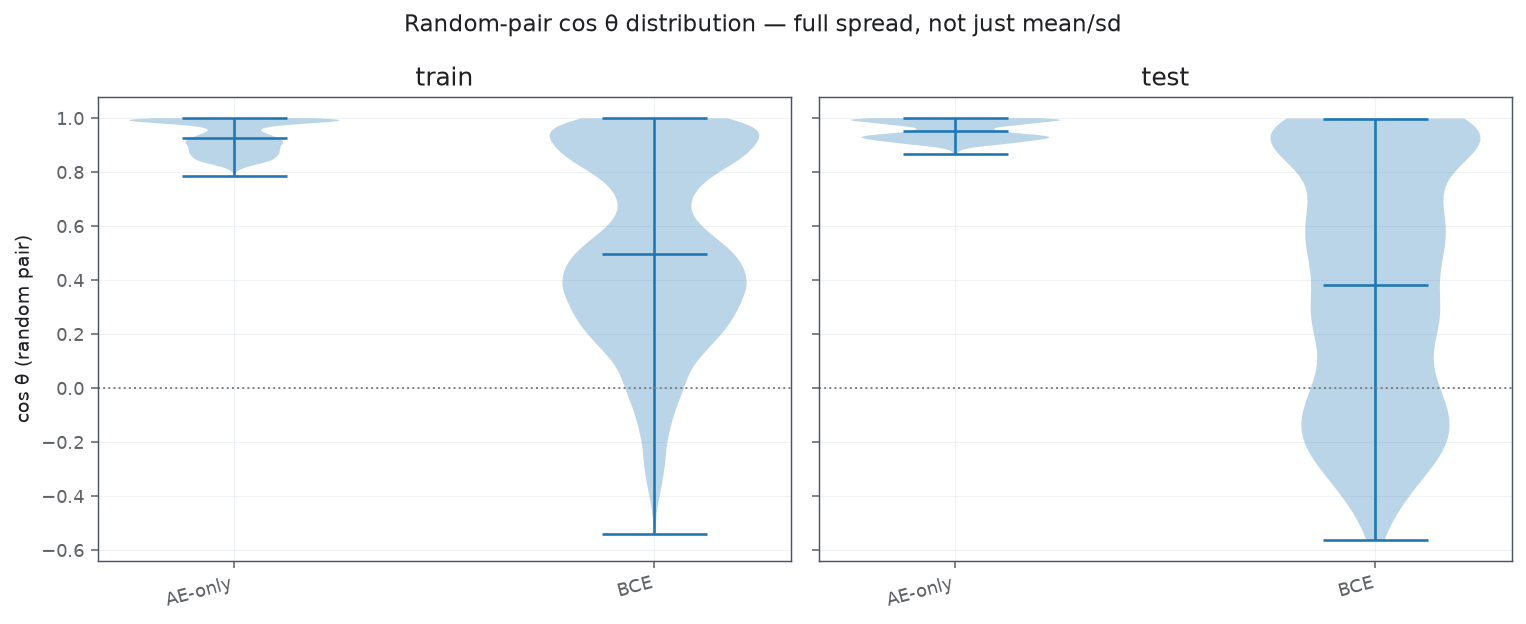

In [7]:
import matplotlib.pyplot as plt

split_names = list(shared_ids_by_split)
model_keys = ["baseline", "predictive"]
model_labels = [MODEL_LABELS[key] for key in model_keys]

figure, axes = plt.subplots(1, len(split_names), figsize=(5.5 * len(split_names), 4.5), dpi=theme.figure_dpi, sharey=True)
if len(split_names) == 1:
    axes = [axes]
for axis, split_name in zip(axes, split_names):
    samples = [cos_theta_samples_by_group[(split_name, label)] for label in model_labels]
    axis.violinplot(samples, showmeans=True, showextrema=True)
    axis.axhline(0.0, color="grey", linestyle=":", linewidth=1)
    axis.set_xticks(range(1, len(model_labels) + 1))
    axis.set_xticklabels(model_labels, rotation=15, ha="right")
    axis.set(ylabel="cos θ (random pair)" if axis is axes[0] else "", title=split_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Random-pair cos θ distribution — full spread, not just mean/sd", fontsize=12)
figure.tight_layout()

## Dimension usage

### Methodology
#### Theoretical
- Whether the latent uses most of its available 8 (canonicalized) dimensions or
  concentrates variance onto a handful of them — a compressed representation has
  less room to encode independent factors of variation.

#### Implementation
- Eigenvalue spectrum of $\operatorname{Cov}(u)$ (`geometry.dimension_usage`,
  population covariance, `ddof=0`, so $\operatorname{tr} \le 10$ holds exactly),
  reduced to `effective_rank` (exponential Shannon entropy of the normalized
  spectrum) and `participation_ratio`. One eigenvalue is expected to be ~0 by
  construction (`geometria_latentu.md` §2.2/§3.2) — a pipeline check, not a finding.

### Notes
- AE-only's participation ratio is ~1.9-2.0 (effectively 2 of the available 8
  dimensions used) vs. BCE's ~2.0-3.3 — BCE uses more of the sphere's capacity,
  though neither is close to using all 8. Visible directly in the eigenvalue-spectrum
  plot: BCE's curve sits above AE-only's at every rank and decays more gradually.


### Wnioski 

- Tutaj mamy przypadek, że w test secie większośc pixeli jest z konkrentej klasy anntoacji, dlatego uzywa mniejszego wymiaru, bo wszystkei jest z jednej grupy m/z. 
- BCE zmusza model do wykorzystaina większej przestrzeni

In [8]:
dimension_rows = []
spectra_by_key = {}
for split_name in shared_ids_by_split:
    for model_key in ("baseline", "predictive"):
        u = u_by_split_model[(split_name, model_key)]
        result = geometry.dimension_usage(u)
        spectra_by_key[(split_name, model_key)] = result["eigenvalues"]
        dimension_rows.append({
            "split": split_name,
            "model": MODEL_LABELS[model_key],
            "trace": result["trace"],
            "effective_rank": result["effective_rank"],
            "participation_ratio": result["participation_ratio"],
        })

pd.DataFrame(dimension_rows)


,split,model,trace,effective_rank,participation_ratio
0,train,AE-only,0.734855,2.777075,1.898121
1,train,BCE,5.034307,4.529865,3.267879
2,test,AE-only,0.463119,2.554138,1.992395
3,test,BCE,6.027739,2.782806,2.001006


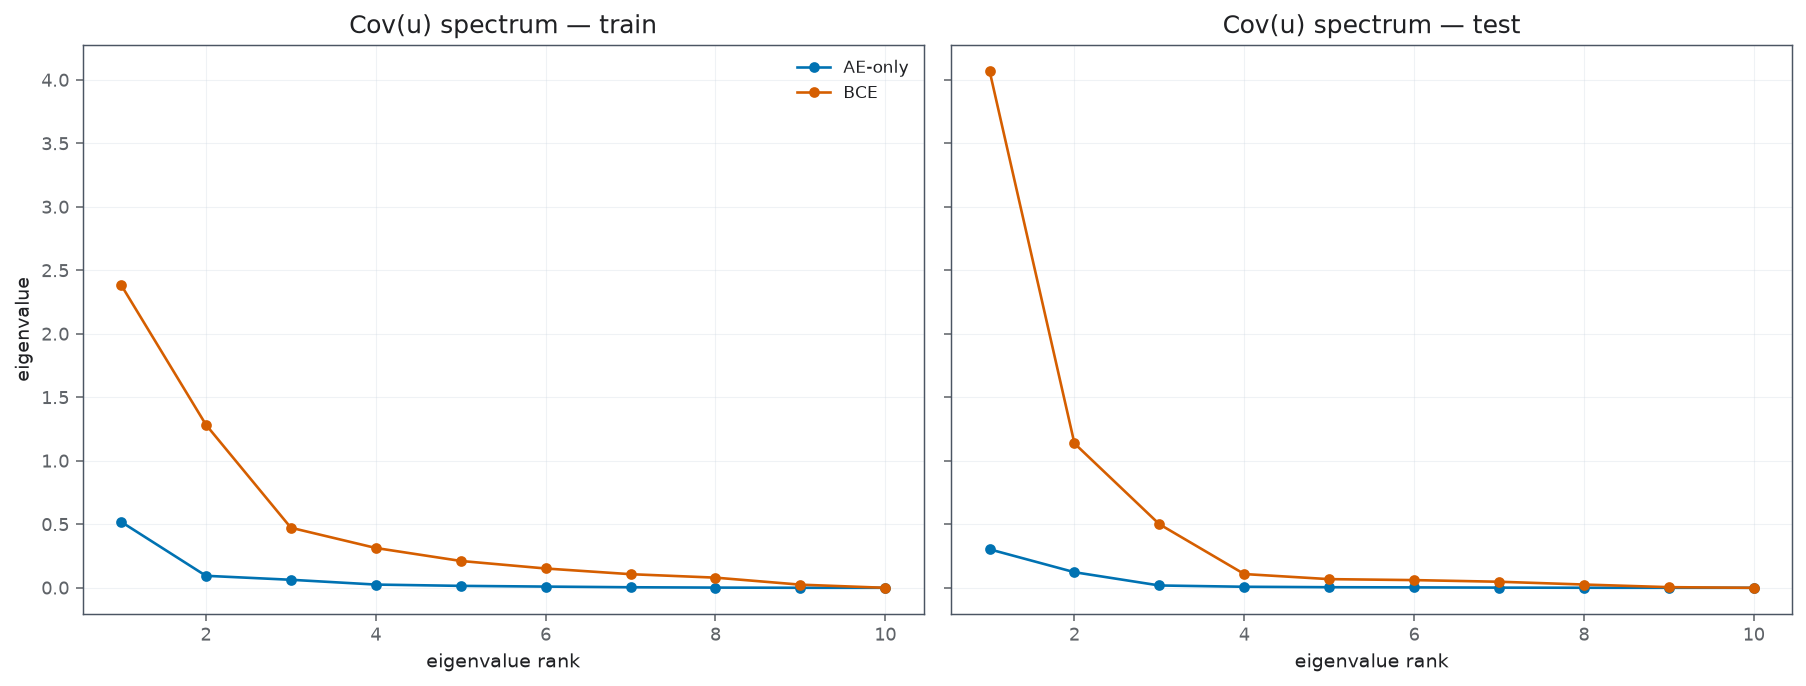

In [9]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(1, 2, figsize=(13.0, 5.0), dpi=theme.figure_dpi, sharey=True)
for ax, split_name in zip(axes, shared_ids_by_split):
    for index, model_key in enumerate(("baseline", "predictive")):
        label = MODEL_LABELS[model_key]
        ax.plot(
            np.arange(1, 11), spectra_by_key[(split_name, model_key)],
            marker="o", color=theme.color_for_model(label, index), label=label,
        )
    ax.set(xlabel="eigenvalue rank", title=f"Cov(u) spectrum — {split_name}")
    ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
axes[0].set_ylabel("eigenvalue")
axes[0].legend(frameon=theme.legend_frame)
figure.tight_layout()


## Intrinsic dimension (TwoNN)

### Methodology
#### Theoretical
- A complementary, non-linear estimate of how many dimensions the point cloud
  actually occupies locally (as opposed to `dimension_usage`'s global,
  covariance-based estimate) — expected near 8 (`geometria_latentu.md` §2.2) if the
  representation actually uses the full sphere; a lower estimate suggests the codes
  concentrate on a lower-dimensional subset of it.

#### Implementation
- `geometry.two_nn_intrinsic_dimension(u)` (Facco et al., 2017): uses each point's
  nearest and second-nearest neighbor angular distances; `O(N^2)`, so this is
  computed per split at that split's actual pixel count (2662 train, 42 test).

### Notes
- Train ($N{=}2662$, the robust read): ~5.7-6.0 for both models — some real
  multi-dimensional structure, short of the full 8. The test-split estimates
  (~2.7-3.0, $N{=}42$) are the small-sample-caveated numbers `geometria_latentu.md`
  §10 warned about — not comparable to the train estimates at face value.


In [10]:
two_nn_rows = []
for split_name in shared_ids_by_split:
    for model_key in ("baseline", "predictive"):
        u = u_by_split_model[(split_name, model_key)]
        two_nn_rows.append({
            "split": split_name,
            "model": MODEL_LABELS[model_key],
            "n_samples": u.shape[0],
            "two_nn_intrinsic_dimension": geometry.two_nn_intrinsic_dimension(u),
        })

two_nn_frame = pd.DataFrame(two_nn_rows)
two_nn_frame


,split,model,n_samples,two_nn_intrinsic_dimension
0,train,AE-only,2662,5.991886
1,train,BCE,2662,5.715953
2,test,AE-only,42,2.750988
3,test,BCE,42,2.957976


## Geometry similarity, neighborhood similarity — AE-only vs. BCE, paired

### Methodology
#### Theoretical
- Do the two models' latents, beyond having similar aggregate shape statistics,
  actually organize the *same pixels* similarly relative to each other? A global
  shape match (e.g. similar `dimension_usage`) does not imply the same local
  neighborhood structure, and vice versa — Procrustes/CKA test global geometric
  alignment, `k`NN-overlap/trustworthiness/continuity test local neighborhood
  preservation.

#### Implementation
- Every metric here is computed on the *same* pixels, row-aligned across the two
  models (`z_by_split_model`'s construction) — a true paired comparison, not two
  independent point clouds: `geometry.procrustes_distance`, `geometry.linear_cka`,
  `geometry.knn_overlap` (k=10, Jaccard of nearest-neighbor sets), and
  `geometry.trustworthiness_continuity` (k=10). `test` has only as many shared
  pixels as `part_1` found (42) — small enough that these are indicative, not
  precise (`geometria_latentu.md` §10); `train` (~2.6k pixels) is the robust read.

### Notes
- Train (same 2662 pixels): Procrustes distance 0.40 (a real shape difference, not
  just noise), linear CKA 0.90 (high — exactly the "CKA stays high even for visibly
  different representations" trap the methodology doc warned about; not a
  contradiction of the Procrustes result), $k$NN-overlap 0.42 (fewer than half of
  each point's 10 nearest neighbors survive between the two models — substantial
  local reorganization), trustworthiness/continuity ~0.99 both directions (the
  *global* rank-order of distances is largely preserved despite that local
  reshuffling).
- The test-split numbers here (kNN-overlap jumps to 0.93) are the $N{=}42$
  small-sample artifact, not evidence that held-out pixels behave differently from
  train pixels.


In [11]:
pairwise_rows = []
for split_name in shared_ids_by_split:
    u_baseline = u_by_split_model[(split_name, "baseline")]
    u_predictive = u_by_split_model[(split_name, "predictive")]
    knn_k = min(KNN_K, u_baseline.shape[0] - 1)
    trust_cont = geometry.trustworthiness_continuity(u_baseline, u_predictive, n_neighbors=knn_k)
    pairwise_rows.append({
        "split": split_name,
        "n_samples": u_baseline.shape[0],
        "procrustes_distance": geometry.procrustes_distance(u_baseline, u_predictive),
        "linear_cka": geometry.linear_cka(u_baseline, u_predictive),
        "knn_overlap": geometry.knn_overlap(u_baseline, u_predictive, k=knn_k),
        "trustworthiness": trust_cont["trustworthiness"],
        "continuity": trust_cont["continuity"],
    })

pd.DataFrame(pairwise_rows)


,split,n_samples,procrustes_distance,linear_cka,knn_overlap,trustworthiness,continuity
0,train,2662,0.400881,0.896602,0.415815,0.991466,0.990260
1,test,42,0.284460,0.966448,0.930952,0.991195,0.993351


## Structure vs. molecule labels (RSA-Spearman)

### Methodology
#### Theoretical
- Whether latent-space angular distance actually correlates with molecule-label
  dissimilarity — a representation could have rich geometric structure
  (`structure_test`, `dimension_usage`) that is nonetheless unrelated to the labels
  the classification head cares about. Only the predictive campaign's dataset
  carries molecule targets (the reconstruction-only baseline has none —
  `report/methodology.md` §2); labels are always pulled from `predictive_partitions`
  regardless of which model's latent is being tested, so the question for AE-only is
  "does a representation that never saw these labels happen to correlate with them
  anyway," and for BCE it is "does the representation actually trained against them
  show the expected correlation."

#### Implementation
- `geometry.rsa_spearman(u, labels, rng, pair_count)`: for a random sample of pixel
  pairs, correlates latent angular distance against label-Jaccard distance via
  Spearman's $r$, with a permutation-based $p$-value.

### Notes
- Both models show a strong, highly significant correlation between latent angle and
  label-Jaccard distance (Spearman $r \approx 0.55$-$0.68$, $p \approx 0$) —
  including AE-only, which never saw a single label. Plausible reading: similar
  molecular content drives similar spectra, which drives similar
  reconstruction-optimal codes, independent of whether a classification head is
  present.
- Training on the labels (BCE) did *not* straightforwardly increase this
  correlation — it is lower for BCE than AE-only on train (0.545 vs. 0.655) and only
  slightly higher on test (0.677 vs. 0.646). Worth returning to once `part_6`'s
  actual per-class prediction quality is in hand, rather than reading too much into
  RSA alone.


In [12]:
def fetch_targets(partitions, split_name: str, spectrum_ids: list[int]) -> np.ndarray:
    dataset = getattr(partitions, split_name)
    index_by_id = {sid: index for index, sid in enumerate(partitions.manifest.assignments[split_name])}
    ordered_indices = [index_by_id[sid] for sid in spectrum_ids]
    return np.stack([dataset[index][2]["molecule"].numpy() for index in ordered_indices])


rsa_rows = []
rsa_rng = np.random.default_rng(RANDOM_SEED + 1)
for split_name, ids in shared_ids_by_split.items():
    labels = fetch_targets(predictive_partitions, split_name, ids)
    for model_key in ("baseline", "predictive"):
        u = u_by_split_model[(split_name, model_key)]
        pairs = min(PAIR_COUNT, u.shape[0] * (u.shape[0] - 1))
        result = geometry.rsa_spearman(u, labels, rsa_rng, pair_count=pairs)
        rsa_rows.append({"split": split_name, "model": MODEL_LABELS[model_key], **result})

pd.DataFrame(rsa_rows)


,split,model,spearman_r,p_value,pairs
0,train,AE-only,0.655230,0.000000e+00,19991
1,train,BCE,0.544595,0.000000e+00,19993
2,test,AE-only,0.645515,3.043454e-199,1685
3,test,BCE,0.677485,1.659840e-226,1683


## Encoder sensitivity — angular curve

### Methodology
#### Theoretical
- How much does the latent code move, in angle, for a small relative perturbation of
  the input spectrum? A representation compressed onto fewer effective dimensions
  (per `dimension_usage`) has less room to move under a generic perturbation, so this
  is a direct, independent check of that finding via input sensitivity rather than
  static geometry. Neither model here has the contractive penalty (which explicitly
  penalizes this sensitivity), so this is a baseline reading for `part_7`'s
  contractive-vs-not comparison later, not expected to show a strong difference on
  its own basis.

#### Implementation
- $\varepsilon \mapsto \mathbb{E}\,\angle(u(x), u(x+\varepsilon\lVert x\rVert\delta))$,
  $\delta$ a random unit direction (`geometria_latentu.md` §6.3), swept over
  `EPSILONS`, computed on the test pixels only (genuinely unseen by both models).

### Notes
- BCE's latent moves substantially further in angle than AE-only's for the same
  relative input perturbation (e.g. ~33° vs. ~9° at $\varepsilon{=}1.0$) —
  consistent with the dimension-usage finding: a representation compressed onto ~2
  effective dimensions has less room to move under a generic perturbation than one
  using more of the sphere.


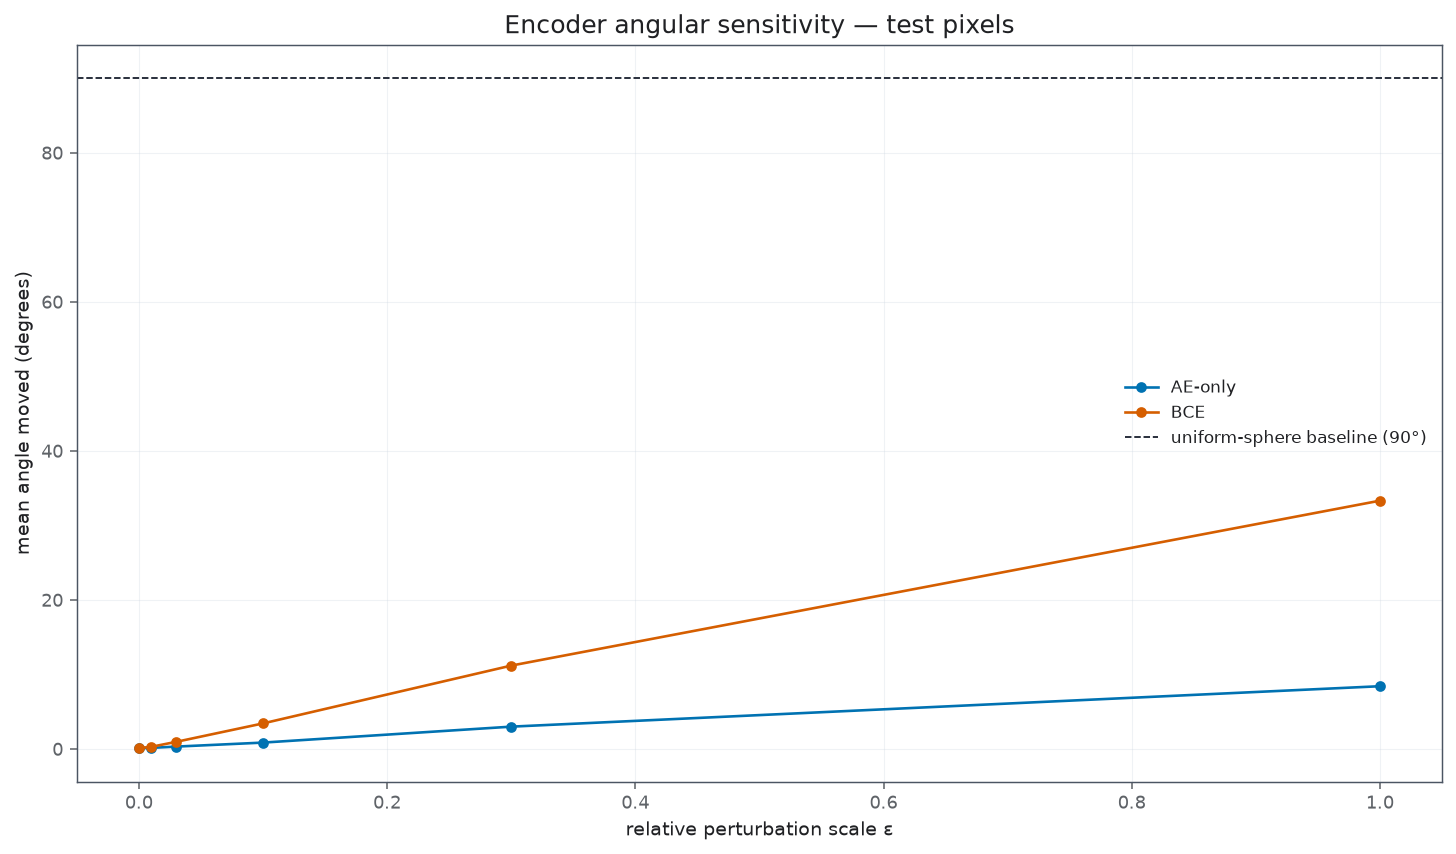

In [13]:
EPSILONS = [0.0, 0.01, 0.03, 0.1, 0.3, 1.0]
sensitivity_rng = np.random.default_rng(RANDOM_SEED + 2)

test_ids = shared_ids_by_split["test"]
test_index_baseline = {sid: i for i, sid in enumerate(baseline_partitions.manifest.assignments["test"])}
test_index_predictive = {sid: i for i, sid in enumerate(predictive_partitions.manifest.assignments["test"])}
baseline_test_spectra = torch.stack(
    [baseline_partitions.test[test_index_baseline[sid]][1] for sid in test_ids]
).float().numpy()
predictive_test_spectra = torch.stack(
    [predictive_partitions.test[test_index_predictive[sid]][1] for sid in test_ids]
).float().numpy()


def make_encode_fn(model, gamma, beta):
    device = next(model.parameters()).device

    def encode_fn(batch: np.ndarray) -> np.ndarray:
        with torch.no_grad():
            tensor_batch = torch.as_tensor(batch, dtype=torch.float32).to(device)
            z = model(tensor_batch)["latent_space"].cpu().numpy()
        return geometry.canonicalize(z, gamma, beta)

    return encode_fn


sensitivity_curves = {
    "baseline": geometry.angular_sensitivity_curve(
        make_encode_fn(baseline_model, baseline_gamma, baseline_beta),
        baseline_test_spectra, EPSILONS, sensitivity_rng,
    ),
    "predictive": geometry.angular_sensitivity_curve(
        make_encode_fn(predictive_model, predictive_gamma, predictive_beta),
        predictive_test_spectra, EPSILONS, sensitivity_rng,
    ),
}

figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
for index, model_key in enumerate(("baseline", "predictive")):
    label = MODEL_LABELS[model_key]
    curve = sensitivity_curves[model_key]
    ax.plot(curve["epsilon"], curve["mean_angle_degrees"], marker="o", color=theme.color_for_model(label, index), label=label)
ax.axhline(90.0, color=theme.baseline_color, linestyle=theme.baseline_line_style, linewidth=theme.reference_line_width, label="uniform-sphere baseline (90°)")
ax.set(xlabel="relative perturbation scale ε", ylabel="mean angle moved (degrees)", title="Encoder angular sensitivity — test pixels")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(frameon=theme.legend_frame)
figure.tight_layout()


## Notes for the next pass

Facts established here, not yet interpreted:

- **Pipeline check passes cleanly**: row sums ~1e-6, norms within ~1e-5 of
  $\sqrt{10}$ for both models on both splits — canonicalization is correct, every
  statistic below is trustworthy on that front.
- **AE-only's latent is far more clustered than BCE's.** `structure_test`:
  AE-only's random-pair $\cos\theta$ has mean ~0.93-0.95 and sd ~0.03-0.06 — far
  below the 1/3 uniform-sphere baseline, i.e. most pairs of points sit close
  together on the sphere. BCE's mean $\cos\theta$ is ~0.38-0.50 with sd ~0.34-0.45
  — much closer to (and on `sd`, past) the uniform value; past-uniform variance
  reads as polarized/multi-cluster structure rather than unstructured noise, not
  as "even more uniform than random."
- **Same story in `dimension_usage`**: AE-only's participation ratio is ~1.9-2.0
  (effectively 2 of the available 8 dimensions used) vs. BCE's ~2.0-3.3 — BCE uses
  more of the sphere's capacity, though neither is close to using all 8. Visible
  directly in the eigenvalue-spectrum plot: BCE's curve sits above AE-only's at
  every rank and decays more gradually.
- **TwoNN** (train, $N{=}2662$, the robust read): ~5.7-6.0 for both models — some
  real multi-dimensional structure, short of the full 8. The test-split estimates
  (~2.7-3.0, $N{=}42$) are the small-sample-caveated numbers `geometria_latentu.md`
  §10 warned about — not comparable to the train estimates at face value.
- **Paired AE-only vs. BCE geometry (train, same 2662 pixels)**: Procrustes
  distance 0.40 (a real shape difference, not just noise), linear CKA 0.90 (high —
  exactly the "CKA stays high even for visibly different representations" trap
  the methodology doc warned about; not a contradiction of the Procrustes result),
  $k$NN-overlap 0.42 (fewer than half of each point's 10 nearest neighbors survive
  between the two models — substantial local reorganization), trustworthiness/
  continuity ~0.99 both directions (the *global* rank-order of distances is
  largely preserved despite that local reshuffling). The test-split numbers here
  (kNN-overlap jumps to 0.93) are the $N{=}42$ small-sample artifact, not evidence
  that held-out pixels behave differently from train pixels.
- **RSA vs. molecule labels**: both models show a strong, highly significant
  correlation between latent angle and label-Jaccard distance (Spearman
  $r \approx 0.55$-$0.68$, $p \approx 0$) — including AE-only, which never saw a
  single label. Plausible reading: similar molecular content drives similar
  spectra, which drives similar reconstruction-optimal codes, independent of
  whether a classification head is present. Training on the labels (BCE) did
  *not* straightforwardly increase this correlation — it is lower for BCE than
  AE-only on train (0.545 vs. 0.655) and only slightly higher on test (0.677 vs.
  0.646). Worth returning to once `part_6`'s actual per-class prediction quality
  is in hand, rather than reading too much into RSA alone.
- **Encoder sensitivity**: BCE's latent moves substantially further in angle than
  AE-only's for the same relative input perturbation (e.g. ~33° vs. ~9° at
  $\varepsilon{=}1.0$) — consistent with the dimension-usage finding: a
  representation compressed onto ~2 effective dimensions has less room to move
  under a generic perturbation than one using more of the sphere.

`part_7` continues this chain: BCE (now the "previous" stage) vs. each of the two
non-contractive contrastive ablations (`grid_0002`, `grid_0003`), using the exact same
battery and the same paired-pixel methodology.
